### 1. Environment Setup & Data Access
Before diving into the preprocessing pipeline, we need to connect our Google Drive. This allows the notebook to directly access the raw audio files and the `final_metadata.csv` provided by the teaching team, as well as giving us a place to export our cleaned dataset later.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Library Imports & Metadata Loading
With our Drive connected, we will now import the essential libraries for this phase: `pandas` for handling our tabular data and `librosa` for audio processing. Next, we will set up the base paths to our dataset and load the `final_metadata.csv` file provided by the teaching team to ensure our directory structure is correct before we begin extracting the true audio durations.

In [ ]:
import pandas as pd
import librosa
import os
import warnings
warnings.filterwarnings('ignore')

# CORRECTED PATH: Colab uses /content/drive/MyDrive/
base_path = '/content/drive/MyDrive/Final-Project-Dataset'
metadata_path = os.path.join(base_path, 'final_metadata.csv')

# Load metadata
try:
    df = pd.read_csv(metadata_path)
    print("Metadata loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print(f"Still can't find it at {metadata_path}.")

Metadata loaded successfully!


,filename,source_url,start_time,end_time,duration_seconds,speaker_description,notes
0,G01_Isfahani_Female_F01_Voice01.mp3,https://telewebion.ir/program/0x1b27139/archive,00:21:22,00:21:18,56,بی بی,notes
1,G01_Isfahani_Female_F02_Voice02.mp3,https://telewebion.ir/program/0x1b27139/archive,00:16:12,00:17:33,56,بی بی,notes
2,G01_Isfahani_Female_F03_Voice03.mp3,https://telewebion.ir/program/0x1b27139/archive,00:13:20,00:14:15,55,بی بی,notes
3,G01_Isfahani_Female_F04_Voice01.mp3,https://www.aparat.com/v/r15m8l5?refererRef=ch...,00:00:07,00:01:03,58,خانم رزیتا کریمی در کانال اپارات خود شعر با له...,none
4,G01_Isfahani_Female_F04_Voice02.mp3,https://www.aparat.com/v/WG1Q9?refererRef=chan...,00:00:03,00:01:01,58,خانم رزیتا کریمی در کانال اپارات خود شعر با له...,none


### 3. Data Auditing & True Duration Extraction
Due to formatting inconsistencies in the original Phase 1 metadata, we cannot rely on the provided `duration_seconds` column. In this step, we dynamically construct the file paths based on the dataset's dialect folder structure and audit our raw files. By leveraging `librosa.get_duration()` directly on the file paths, we efficiently read the audio headers to extract the exact true lengths without loading the heavy audio arrays into memory. This flags any missing or corrupted files early and gives us a reliable statistical distribution to establish our length-filtering thresholds.

In [ ]:
import numpy as np
from tqdm import tqdm

# We assume base_path is already defined as:
# base_path = '/content/drive/MyDrive/Final-Project-Dataset'

def get_audio_info(row):
    filename = row['filename']

    # Extract dialect from filename to find the right subfolder
    # Example: 'G01_Isfahani_Female_F01_Voice01.mp3' -> 'Isfahani'
    dialect_folder = filename.split('_')[1]

    file_path = os.path.join(base_path, dialect_folder, filename)
    exists = os.path.exists(file_path)
    duration = np.nan

    if exists:
        try:
            # librosa.get_duration with 'path' reads the metadata directly, saving RAM and time
            duration = librosa.get_duration(path=file_path)
        except Exception:
            # Catching corrupted files without crashing the loop
            pass

    return pd.Series([exists, duration])

# Apply function with progress bar
tqdm.pandas(desc="Auditing files and extracting true durations")
df[['file_exists', 'true_duration']] = df.progress_apply(get_audio_info, axis=1)

# Audit report
missing_files = (~df['file_exists']).sum()
corrupted_files = df['file_exists'] & df['true_duration'].isna()

print(f"Total rows in metadata: {len(df)}")
print(f"Files missing from Drive: {missing_files}")
print(f"Files corrupted/unreadable: {corrupted_files.sum()}")
print("\n--- True Duration Stats (seconds) ---")
print(df['true_duration'].describe())

Auditing files and extracting true durations: 100%|██████████| 431/431 [07:35<00:00,  1.06s/it]

Total rows in metadata: 431
Files missing from Drive: 0
Files corrupted/unreadable: 0

--- True Duration Stats (seconds) ---
count    431.000000
mean      60.089046
std        4.538121
min       47.995646
25%       57.939592
50%       60.000000
75%       61.446610
max       80.294603
Name: true_duration, dtype: float64


### 4. Length Filtering & Outlier Removal
According to the Phase 1 collection guidelines, optimal audio samples should be between 50 and 70 seconds long. In this step, we apply a strict boolean mask to enforce that rule. By dropping outliers—files that are excessively short or long—alongside any missing or corrupted files flagged in our audit, we guarantee our dataset is uniform and ready for consistent feature extraction.

In [ ]:
# Filter based on Phase 1 rules (50 to 70 seconds)
valid_duration_mask = (df['true_duration'] >= 50) & (df['true_duration'] <= 70)

# Keep only files that exist AND have valid durations
df_filtered = df[df['file_exists'] & valid_duration_mask].copy()

dropped_count = len(df) - len(df_filtered)
print(f"Dropped {dropped_count} files (missing, corrupted, or outside 50-70s range).")
print(f"Remaining files for processing: {len(df_filtered)}")

# Optional: Reset index for clean iteration later
df_filtered.reset_index(drop=True, inplace=True)

Dropped 21 files (missing, corrupted, or outside 50-70s range).
Remaining files for processing: 410


### 5. Core Audio Preprocessing Engine
Before we can evaluate the true quality of our audio files, we need to standardize their physical properties. This helper function serves as our core processing engine. It loads each file and standardizes the sampling rate to 16kHz (the gold standard for capturing human speech frequencies). Next, it trims away dead silence at the beginning and end of the recording. Finally, it applies peak normalization—scaling the audio so the loudest point hits a uniform baseline. This ensures consistent volume across all files without artificially distorting the natural dynamics of the speakers' voices.

In [ ]:
def base_preprocess_audio(file_path):
    """
    Loads, resamples (16kHz), trims silence, and peak-normalizes the audio.
    Returns the processed audio array, sampling rate, and new duration.
    """
    try:
        # 1. Load & Resample to 16kHz
        y, sr = librosa.load(file_path, sr=16000)

        # 2. Trim Silence
        y_trimmed, _ = librosa.effects.trim(y, top_db=20)

        # 3. Peak Normalization
        max_peak = np.max(np.abs(y_trimmed))
        if max_peak > 0:
            y_normalized = y_trimmed / max_peak
        else:
            y_normalized = y_trimmed

        # Calculate new duration
        new_duration = len(y_normalized) / sr

        return y_normalized, sr, new_duration

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None, None, np.nan

### 6. Audio Quality Triage: SNR & Voice Activity Detection (VAD)
Now that our audio is physically standardized, we need to evaluate its acoustic quality. Instead of manually listening to hundreds of files, we built an automated triage system. This code calculates a mathematical proxy for Signal-to-Noise Ratio (SNR) by comparing the loudest parts of the audio (speech) to the quietest (background noise). Simultaneously, it leverages PyTorch and Silero VAD—a pre-trained deep learning model—to determine exactly what percentage of the file contains actual human speech. Running this analysis over the dataset gives us the statistical spread we need to objectively categorize our audio into "OK," "Fixable," and "Trash" bins.

In [ ]:
import torch

# --- 1. Load Silero VAD Model ---
# We load this once outside the loop so it doesn't slow us down
print("Loading Silero VAD model...")
vad_model, vad_utils = torch.hub.load(repo_or_dir='snakers4/silero-vad',
                                      model='silero_vad',
                                      force_reload=False,
                                      onnx=False)
(get_speech_timestamps, _, _, _, _) = vad_utils

# --- 2. Helper Functions ---
def base_preprocess_audio(file_path):
    """Loads, resamples to 16kHz, trims silence, and peak-normalizes."""
    try:
        y, sr = librosa.load(file_path, sr=16000)
        y_trimmed, _ = librosa.effects.trim(y, top_db=20)
        max_peak = np.max(np.abs(y_trimmed))
        y_normalized = y_trimmed / max_peak if max_peak > 0 else y_trimmed
        return y_normalized, sr
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None, None

def calculate_snr(y):
    """Calculates SNR comparing the top 10% loudest frames to the bottom 10% quietest."""
    rms = librosa.feature.rms(y=y)[0]
    sorted_rms = np.sort(rms)

    # Take top 10% (speech) and bottom 10% (background)
    n = max(1, int(len(sorted_rms) * 0.1))
    top_10 = sorted_rms[-n:]
    bottom_10 = sorted_rms[:n]

    mean_top = np.mean(top_10)
    mean_bottom = np.mean(bottom_10) if np.mean(bottom_10) > 0 else 1e-10

    # SNR formula in decibels (dB)
    snr_db = 20 * np.log10(mean_top / mean_bottom)
    return snr_db

def calculate_vad_percentage(y, sr):
    """Calculates what percentage of the file contains actual human speech."""
    wav_tensor = torch.FloatTensor(y)
    # Get timestamps of speech chunks
    timestamps = get_speech_timestamps(wav_tensor, vad_model, sampling_rate=sr)

    if not timestamps:
        return 0.0

    total_speech_samples = sum([t['end'] - t['start'] for t in timestamps])
    return (total_speech_samples / len(y)) * 100

# --- 3. The Main Triage Loop ---
def triage_file(row):
    filename = row['filename']
    dialect_folder = filename.split('_')[1]
    file_path = os.path.join(base_path, dialect_folder, filename) # Assuming base_path is set

    y, sr = base_preprocess_audio(file_path)

    if y is None:
        return pd.Series([np.nan, np.nan])

    snr = calculate_snr(y)
    vad_pct = calculate_vad_percentage(y, sr)

    return pd.Series([snr, vad_pct])

print("Running files through Triage Analysis...")
tqdm.pandas(desc="Calculating SNR and VAD")
# We apply this to the df_filtered from earlier (the 50-70s length files)
df_filtered[['snr_db', 'vad_percentage']] = df_filtered.progress_apply(triage_file, axis=1)

# Look at the stats so we can pick our thresholds
print("\n--- Triage Stats ---")
print(df_filtered[['snr_db', 'vad_percentage']].describe())

Loading Silero VAD model...
The repository snakers4_silero-vad does not belong to the list of trusted repositories and as such cannot be downloaded. Do you trust this repository and wish to add it to the trusted list of repositories (y/N)?y
Downloading: "https://github.com/snakers4/silero-vad/zipball/master" to /root/.cache/torch/hub/master.zip
Running files through Triage Analysis...


Calculating SNR and VAD: 100%|██████████| 410/410 [08:56<00:00,  1.31s/it]


--- Triage Stats ---
           snr_db  vad_percentage
count  410.000000      410.000000
mean    35.265025       88.231443
std     12.469638       11.832442
min     12.299399        2.164026
25%     26.983015       82.635908
50%     32.567196       91.077927
75%     40.561934       96.787132
max    123.924980      100.000000


### 7. Final Execution Pipeline: Classification, Filtering, & Export
With our quality thresholds officially set, we reach the grand finale of the preprocessing pipeline. This master block acts as the traffic controller for our dataset. It first categorizes every file into "OK," "Fixable," or "Trash." Files flagged as "Trash" are instantly dropped to protect the integrity of our machine learning models. For the "Fixable" files, we step in with a surgical Butterworth bandpass filter (80 Hz to 7,500 Hz) to clear out low-end rumbles and high-end hisses, carefully staying below the Nyquist limit to avoid math errors. Finally, the surviving high-quality audio files are written out to our personal Drive alongside a brand new, streamlined metadata CSV.

In [ ]:
import soundfile as sf
from scipy.signal import butter, sosfilt

# --- 1. Triage Classification ---
def classify_file(row):
    vad = row['vad_percentage']
    snr = row['snr_db']

    # Safety check for corrupted files
    if pd.isna(vad) or pd.isna(snr):
        return 'Trash'

    if vad < 60 or snr < 20:
        return 'Trash'
    elif vad >= 80 and snr >= 28:
        return 'OK'
    else:
        return 'Fixable'

df_filtered['status'] = df_filtered.apply(classify_file, axis=1)

# --- Print Terminal Statistics ---
print("\n========== TRIAGE STATISTICS ==========")
print(df_filtered['status'].value_counts())
print("=======================================\n")

# --- 2. Bandpass Filter Helper ---
def apply_bandpass(y, sr, lowcut=80.0, highcut=7500.0, order=5):
    """
    Applies a Butterworth bandpass filter.
    highcut is set to 7500Hz to stay strictly below the 8000Hz Nyquist limit.
    """
    # Modern scipy allows passing fs (sampling rate) directly, handling the math for us
    sos = butter(order, [lowcut, highcut], btype='band', output='sos', fs=sr)
    y_filtered = sosfilt(sos, y)
    return y_filtered

# --- 3. Execution Pipeline ---
my_personal_drive = '/content/drive/MyDrive/ML_Phase2_Processed'
processed_dir = os.path.join(my_personal_drive, 'Processed_Audio')
os.makedirs(processed_dir, exist_ok=True)

final_data = []

print("Starting Final Processing & Saving Pipeline...")
for idx, row in tqdm(df_filtered.iterrows(), total=len(df_filtered), desc="Processing & Saving"):
    status = row['status']

    # Immediately drop trash
    if status == 'Trash':
        continue

    filename = row['filename']
    dialect_folder = filename.split('_')[1]
    file_path = os.path.join(base_path, dialect_folder, filename)
    save_path = os.path.join(processed_dir, filename)

    # Base preprocess (load, resample, trim, normalize)
    y, sr = base_preprocess_audio(file_path)

    if y is None:
        continue

    # If fixable, apply bandpass filter to clean the mud
    if status == 'Fixable':
        y = apply_bandpass(y, sr)

    # Save to disk
    sf.write(save_path, y, sr)

    # Extract metadata for the handoff CSV
    new_duration = len(y) / sr
    dialect = filename.split('_')[1]
    gender = filename.split('_')[2]
    speaker_id = filename.split('_')[3]

    final_data.append({
        'filename': filename,
        'dialect': dialect,
        'gender': gender,
        'speaker_id': speaker_id,
        'processed_duration': new_duration,
        'triage_status': status
    })

# --- 4. Save Final CSV ---
df_handoff = pd.DataFrame(final_data)
handoff_csv_path = os.path.join(my_personal_drive, 'processed_metadata_handoff.csv')
df_handoff.to_csv(handoff_csv_path, index=False)

print(f"\nPipeline Complete! Successfully saved {len(df_handoff)} high-quality files.")
print(f"Audio saved to: {processed_dir}")
print(f"Handoff CSV saved to: {handoff_csv_path}")


========== TRIAGE STATISTICS ==========
status
OK         225
Fixable    154
Trash       31
Name: count, dtype: int64

Starting Final Processing & Saving Pipeline...


Processing & Saving: 100%|██████████| 410/410 [11:50<00:00,  1.73s/it]



Pipeline Complete! Successfully saved 379 high-quality files.
Audio saved to: /content/drive/MyDrive/ML_Phase2_Processed/Processed_Audio
Handoff CSV saved to: /content/drive/MyDrive/ML_Phase2_Processed/processed_metadata_handoff.csv


### 8. Library Imports for Feature Extraction
Building on top of the preprocessing pipeline from the previous section,
we now import the additional libraries needed for feature extraction and analysis.
`librosa` handles all audio feature computation, `sklearn` provides PCA and
scaling utilities for our preliminary analysis, and `matplotlib`/`seaborn`
are used for visualizing the feature distributions.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tqdm import tqdm

# The handoff CSV and processed audio directory are inherited from the
# previous pipeline section. We define only the new output path here.
FEATURES_OUTPUT_CSV = os.path.join(my_personal_drive, 'features_dataset.csv')

# Target sample rate — must match the preprocessing step
SR = 16000

print(f"Starting feature extraction on {len(df_handoff)} processed files.")
print(f"Audio directory: {processed_dir}")

Starting feature extraction on 379 processed files.
Audio directory: /content/drive/MyDrive/ML_Phase2_Processed/Processed_Audio


### 9. Feature Extraction Functions
After cleaning and standardizing the raw audio in the previous phase, we
need to convert each audio file into a fixed-length numerical vector.
Since features like MFCC and Log-Mel Spectrogram vary over time (they
produce a 2D matrix per file), we summarize each coefficient using
statistical aggregates: mean and standard deviation. This collapses
the time dimension and gives us a single flat vector per file that
any ML model in Phase 3 can consume directly.

The five dialects in this project (Torki, Kordi, Mashhadi, Isfahani,
Gilaki) are all Persian-context dialects. Their key differences lie in
vowel quality, intonation contour, and consonant articulation — so we
prioritize features that are sensitive to spectral shape, harmonic
structure, and melodic pattern. We extract seven complementary groups:

  - MFCC (13)           → compact phonetic / vocal tract shape
  - Log-Mel (13 bands)  → full spectral energy, reduced to avoid
                          overfitting on a small dataset (~300 files)
  - Pitch / F0          → primary gender cue; prosody cue for dialect
  - Chroma              → intonation contour and harmonic pattern,
                          highly sensitive to dialect-specific prosody
  - Spectral Contrast   → harmonic vs. noise ratio across sub-bands
  - Zero Crossing Rate  → fricative density, voicing characteristics
  - RMS Energy          → loudness dynamics and speaking style


In [ ]:
def extract_mfcc(y, sr, n_mfcc=13):
    """
    Mel-Frequency Cepstral Coefficients (MFCC)

    How it is extracted:
        The signal is windowed into short frames, a DFT is applied to
        each frame, the power spectrum is mapped onto the Mel scale,
        log-compressed, and finally decorrelated with a DCT. The result
        is n_mfcc coefficients per frame.

    Why it is useful:
        MFCCs are the standard compact representation of vocal tract
        shape. The five dialects in this project differ primarily in
        vowel quality (e.g., the Persian /a/ is realized differently in
        Isfahani vs. Mashhadi), and these vowel differences are directly
        encoded in the lower MFCC coefficients. Gender differences in
        vocal tract length also shift the overall MFCC envelope.

    Advantages: compact, robust, well-understood, very low compute cost.
    Limitations: discards phase information and fine temporal dynamics;
        coefficient 0 (energy) can dominate if not normalized separately.

    Output: 13 coefficients × (mean + std) = 26 features
    """
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    features = {}
    for i in range(n_mfcc):
        features[f'mfcc_{i+1}_mean'] = np.mean(mfcc[i])
        features[f'mfcc_{i+1}_std']  = np.std(mfcc[i])
    return features


def extract_log_mel(y, sr, n_mels=13):
    """
    Log-Mel Spectrogram (reduced to 13 bands)

    How it is extracted:
        A standard STFT is computed, the power spectrum is projected
        onto n_mels triangular filterbanks spaced on the Mel scale,
        and the result is converted to decibels.

    Why it is useful:
        Captures the full spectral energy distribution without the DCT
        compression of MFCC, preserving richer detail about how energy
        is spread across frequency bands. Different dialects produce
        characteristic spectral envelopes in their vowel sounds.

    Why 13 bands instead of 40 or 128:
        The combined dataset has at most ~300 files per dialect (15-20
        files × up to 3 groups × 5 dialects). Using 40+ bands would
        produce 80+ Log-Mel features from a single extractor, causing
        the feature matrix to become very high-dimensional relative to
        the number of samples and increasing the risk of overfitting in
        Phase 3 classifiers. 13 bands keeps spectral resolution useful
        while keeping the feature count balanced with MFCC.

    Advantages: richer spectral resolution than MFCC; complements MFCC
        by preserving energy information that the DCT discards.
    Limitations: still sensitive to recording environment and microphone
        frequency response; requires careful normalization.

    Output: 13 bands × (mean + std) = 26 features
    """
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    features = {}
    for i in range(n_mels):
        features[f'logmel_{i+1}_mean'] = np.mean(log_mel[i])
        features[f'logmel_{i+1}_std']  = np.std(log_mel[i])
    return features


def extract_pitch(y, sr):
    """
    Fundamental Frequency / Pitch (F0) via PYIN

    How it is extracted:
        PYIN (probabilistic YIN) estimates the fundamental frequency
        frame-by-frame and also returns a voiced/unvoiced flag per
        frame. We compute statistics only over voiced frames to avoid
        polluting the mean with silence or unvoiced consonants.

    Why it is useful:
        F0 is the single most discriminative feature for gender: female
        speakers in Persian typically range 180-255 Hz, male speakers
        85-165 Hz, with very little overlap. Additionally, Persian
        dialects have distinct intonation patterns — for example,
        Isfahani and Gilaki are known for their characteristic
        melodic contours — which leave a signature in F0 statistics.

    Advantages: direct physical correlate of gender; interpretable;
        captures dialect-specific prosody.
    Limitations: PYIN is the slowest extractor in this pipeline; it
        can produce NaN for short unvoiced segments, which we handle
        by returning zeros when no voiced frames are found.

    Output: 4 features (mean, std, min, max over voiced frames)
    """
    f0, voiced_flag, _ = librosa.pyin(
        y,
        fmin=librosa.note_to_hz('C2'),  # ~65 Hz — below any human voice
        fmax=librosa.note_to_hz('C7'),  # ~2093 Hz — above any human voice
        sr=sr
    )
    voiced_f0 = f0[voiced_flag]

    if len(voiced_f0) == 0:
        # No voiced frames found — return zeros rather than crashing
        return {'pitch_mean': 0.0, 'pitch_std': 0.0,
                'pitch_min':  0.0, 'pitch_max': 0.0}

    return {
        'pitch_mean': float(np.mean(voiced_f0)),
        'pitch_std':  float(np.std(voiced_f0)),
        'pitch_min':  float(np.min(voiced_f0)),
        'pitch_max':  float(np.max(voiced_f0)),
    }


def extract_chroma(y, sr, n_chroma=12):
    """
    Chroma Features (Chroma STFT)

    How it is extracted:
        The power spectrum is mapped onto the 12 pitch classes of the
        Western chromatic scale (C, C#, D, ..., B), then averaged over
        time. Each bin captures the total energy associated with that
        pitch class regardless of octave.

    Why it is useful:
        This is the feature most directly targeted at dialect
        discrimination in this project. Persian dialects differ
        significantly in their intonation contours (melodic patterns):
        - Isfahani speech is known for its distinctive sing-song prosody
        - Gilaki has rising intonation patterns uncommon in standard Persian
        - Mashhadi has a characteristic flat-then-falling contour
        These dialect-specific melodic habits create consistent energy
        distributions across pitch classes that chroma captures well.
        Chroma is also more robust to timbre changes than raw spectral
        features, since it folds octaves together.

    Advantages: dialect-sensitive; robust to speaker differences;
        captures prosodic melody without requiring explicit F0 tracking.
    Limitations: designed originally for music; may be confused by
        strong background harmonics in noisy recordings.

    Output: 12 pitch classes × (mean + std) = 24 features
    """
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=n_chroma)
    features = {}
    for i in range(n_chroma):
        features[f'chroma_{i+1}_mean'] = np.mean(chroma[i])
        features[f'chroma_{i+1}_std']  = np.std(chroma[i])
    return features


def extract_spectral_contrast(y, sr, n_bands=6):
    """
    Spectral Contrast

    How it is extracted:
        The spectrum is divided into n_bands sub-bands plus one residual
        high-frequency band. For each band the difference between the
        peak energy (spectral peaks) and the valley energy (spectral
        valleys) is computed frame-by-frame.

    Why it is useful:
        Harmonic-rich speech — typical of dialects with many voiced
        sonorants or long vowels — shows high contrast between peaks
        and valleys. Dialects with more fricatives or aspiration show
        lower contrast. The pattern across sub-bands acts as a
        fingerprint of the dialect's phoneme inventory.

    Advantages: captures harmonic structure beyond simple spectral
        shape; relatively robust to overall loudness variations.
    Limitations: sensitive to background noise bleeding into the
        spectral valleys; fixed band boundaries may not align perfectly
        with dialect-relevant frequency regions.

    Output: (n_bands + 1) × (mean + std) = 14 features
    """
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_bands=n_bands)
    features = {}
    for i in range(contrast.shape[0]):
        features[f'sc_{i+1}_mean'] = np.mean(contrast[i])
        features[f'sc_{i+1}_std']  = np.std(contrast[i])
    return features


def extract_zcr(y):
    """
    Zero Crossing Rate (ZCR)

    How it is extracted:
        Counts how many times the waveform amplitude crosses zero per
        short frame and summarizes the resulting time series.

    Why it is useful:
        A high ZCR indicates noisy, fricative-heavy, or unvoiced
        speech segments; a low ZCR indicates voiced, harmonic segments.
        Dialects differ in their density of fricatives and affricates
        (e.g., Kordi and Torki have consonant clusters uncommon in
        standard Persian), which produces a characteristic average ZCR.

    Advantages: extremely fast to compute; provides a complementary
        voicing-based view that spectral features can miss.
    Limitations: a global aggregate — temporal dynamics are lost.

    Output: 2 features (mean, std)
    """
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    return {
        'zcr_mean': float(np.mean(zcr)),
        'zcr_std':  float(np.std(zcr)),
    }


def extract_rms(y):
    """
    Root Mean Square (RMS) Energy

    How it is extracted:
        Computes the RMS amplitude within each short frame and
        summarizes the resulting energy envelope statistically.

    Why it is useful:
        Speaking style and prosodic emphasis vary across dialects and
        genders. The dynamic range (std) and peak loudness (max)
        reflect how much the speaker varies their volume over time,
        which is a prosodic marker that differs between dialects.
        Note: since peak normalization was applied in preprocessing,
        absolute values are less informative than the std/max ratio.

    Advantages: simple, fast, and complementary to spectral features.
    Limitations: peak normalization in the preprocessing step reduces
        cross-file variance, so this feature is less discriminative
        here than it would be on un-normalized audio.

    Output: 3 features (mean, std, max)
    """
    rms = librosa.feature.rms(y=y)[0]
    return {
        'rms_mean': float(np.mean(rms)),
        'rms_std':  float(np.std(rms)),
        'rms_max':  float(np.max(rms)),
    }


def extract_all_features(file_path):
    """
    Master feature extraction function.

    Loads a preprocessed audio file and runs all seven feature
    extractors in sequence, returning a single flat dictionary of
    numeric values ready to be appended as one row in the feature
    DataFrame.

    Returns None if the file cannot be loaded (corrupted or missing),
    so the caller can safely skip it without crashing the loop.
    """
    try:
        y, sr = librosa.load(file_path, sr=SR)
    except Exception as e:
        print(f"  [ERROR] Could not load {os.path.basename(file_path)}: {e}")
        return None

    features = {}
    features.update(extract_mfcc(y, sr))
    features.update(extract_log_mel(y, sr))
    features.update(extract_pitch(y, sr))
    features.update(extract_chroma(y, sr))
    features.update(extract_spectral_contrast(y, sr))
    features.update(extract_zcr(y))
    features.update(extract_rms(y))
    return features


### 10. Main Feature Extraction Loop
With our extraction functions defined, we iterate over every file that
survived the preprocessing pipeline. For each file we load the processed
audio, run all seven extractors, and merge the resulting feature dict
with the file's metadata (dialect, gender, speaker ID) into a single
record. Files that fail to load are collected in a separate list so we
can audit them after the loop without interrupting the pipeline.

The final DataFrame has one row per audio file and one column per
extracted feature (plus the four metadata columns), producing the
tabular dataset required as input for Phase 3.

In [ ]:
results      = []
failed_files = []

print("Running feature extraction pipeline...")
for idx, row in tqdm(df_handoff.iterrows(), total=len(df_handoff),
                     desc="Extracting features"):
    file_path = os.path.join(processed_dir, row['filename'])

    # Skip files that were not written to disk during preprocessing
    if not os.path.exists(file_path):
        failed_files.append(row['filename'])
        continue

    feats = extract_all_features(file_path)
    if feats is None:
        failed_files.append(row['filename'])
        continue

    # Prepend metadata so it appears as the first columns in the CSV
    record = {
        'filename':   row['filename'],
        'dialect':    row['dialect'],
        'gender':     row['gender'],
        'speaker_id': row['speaker_id'],
    }
    record.update(feats)
    results.append(record)

df_features = pd.DataFrame(results)

print(f"\n========== EXTRACTION SUMMARY ==========")
print(f"Successfully processed : {len(df_features)} files")
print(f"Failed / skipped       : {len(failed_files)} files")
print(f"Features per file      : {df_features.shape[1] - 4}")
print(f"Final dataset shape    : {df_features.shape}")
print(f"=========================================")

if failed_files:
    print("\nFailed files:")
    for f in failed_files:
        print(f"  - {f}")

Running feature extraction pipeline...


Extracting features: 100%|██████████| 379/379 [1:43:29<00:00, 16.38s/it]


========== EXTRACTION SUMMARY ==========
Successfully processed : 379 files
Failed / skipped       : 0 files
Features per file      : 99
Final dataset shape    : (379, 103)


### 11. Save Final Feature Dataset
The feature DataFrame is saved as a CSV file that will be used as the
direct input to Phase 3 (classification and clustering). We also print
a per-group feature count so the team can verify that all seven
extractors ran and contributed the expected number of columns.

In [ ]:
df_features.to_csv(FEATURES_OUTPUT_CSV, index=False)
print(f"Feature dataset saved to: {FEATURES_OUTPUT_CSV}")

# Per-group feature count — useful for the Phase 3 report
groups = {
    'MFCC (mean+std)':                [c for c in df_features.columns if c.startswith('mfcc_')],
    'Log-Mel Spectrogram (mean+std)': [c for c in df_features.columns if c.startswith('logmel_')],
    'Pitch / F0':                     [c for c in df_features.columns if c.startswith('pitch_')],
    'Chroma (mean+std)':              [c for c in df_features.columns if c.startswith('chroma_')],
    'Spectral Contrast (mean+std)':   [c for c in df_features.columns if c.startswith('sc_')],
    'Zero Crossing Rate':             [c for c in df_features.columns if c.startswith('zcr_')],
    'RMS Energy':                     [c for c in df_features.columns if c.startswith('rms_')],
}
print("\n--- Feature count by group ---")
for name, cols in groups.items():
    print(f"  {name:42s}: {len(cols):3d}")
print(f"  {'Metadata columns':42s}:   4")
print(f"  {'TOTAL':42s}: {df_features.shape[1]:3d}")

display(df_features.head())

Feature dataset saved to: /content/drive/MyDrive/ML_Phase2_Processed/features_dataset.csv

--- Feature count by group ---
  MFCC (mean+std)                           :  26
  Log-Mel Spectrogram (mean+std)            :  26
  Pitch / F0                                :   4
  Chroma (mean+std)                         :  24
  Spectral Contrast (mean+std)              :  14
  Zero Crossing Rate                        :   2
  RMS Energy                                :   3
  Metadata columns                          :   4
  TOTAL                                     : 103


,filename,dialect,gender,speaker_id,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,...,sc_5_std,sc_6_mean,sc_6_std,sc_7_mean,sc_7_std,zcr_mean,zcr_std,rms_mean,rms_std,rms_max
0,G01_Isfahani_Female_F01_Voice01.mp3,Isfahani,Female,F01,-215.111801,115.127754,73.418800,55.477314,-9.480737,31.956133,...,6.375330,37.031834,10.676317,48.112700,6.170109,0.195894,0.184064,0.190916,0.142898,0.590285
1,G01_Isfahani_Female_F02_Voice02.mp3,Isfahani,Female,F02,-187.006363,101.497017,81.595695,42.561954,-7.178339,32.654213,...,4.320523,28.600674,9.713580,48.344904,6.463596,0.101539,0.077039,0.212381,0.151854,0.592788
2,G01_Isfahani_Female_F03_Voice03.mp3,Isfahani,Female,F03,-188.599411,102.653168,80.961441,38.569695,-12.883212,31.845823,...,5.231242,31.134739,11.362026,47.764734,6.735018,0.088570,0.078518,0.226515,0.134520,0.616568
3,G01_Isfahani_Female_F04_Voice01.mp3,Isfahani,Female,F04,-277.480194,130.750320,71.333633,55.522430,-20.318613,35.449512,...,4.417751,24.580162,7.492915,47.370795,11.753202,0.143277,0.127488,0.106714,0.095938,0.413956
4,G01_Isfahani_Female_F04_Voice02.mp3,Isfahani,Female,F04,-197.515289,115.213791,72.708229,53.467823,-5.387085,33.385181,...,4.525311,25.114949,9.248379,53.156823,4.969110,0.165460,0.128391,0.161901,0.113492,0.391531


### 12. Preliminary Data Analysis
Before handing the dataset off to Phase 3, we run a quick exploratory
analysis to verify feature quality and get an early indication of how
well the feature space separates the target classes. We check for
missing values, inspect the distributions of the most interpretable
features, and use PCA to visualize whether gender and dialect clusters
are already visible in the first two principal components.

No missing values found in the feature matrix.

--- Gender distribution ---
gender
Female    201
Male      178
Name: count, dtype: int64

--- Dialect distribution ---
dialect
Torki       108
Kordi        99
Gilaki       90
Isfahani     56
Mashhadi     26
Name: count, dtype: int64


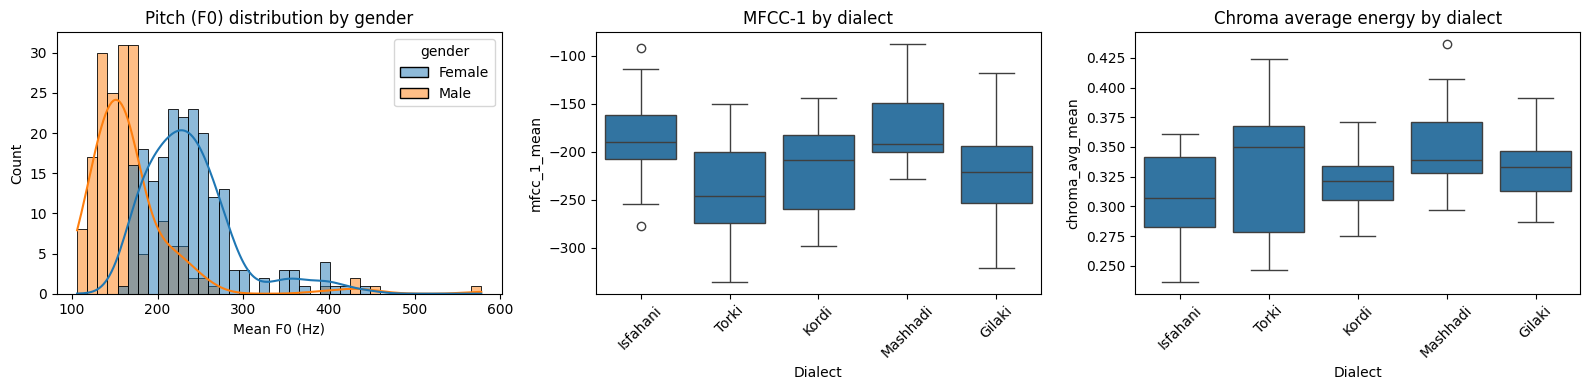

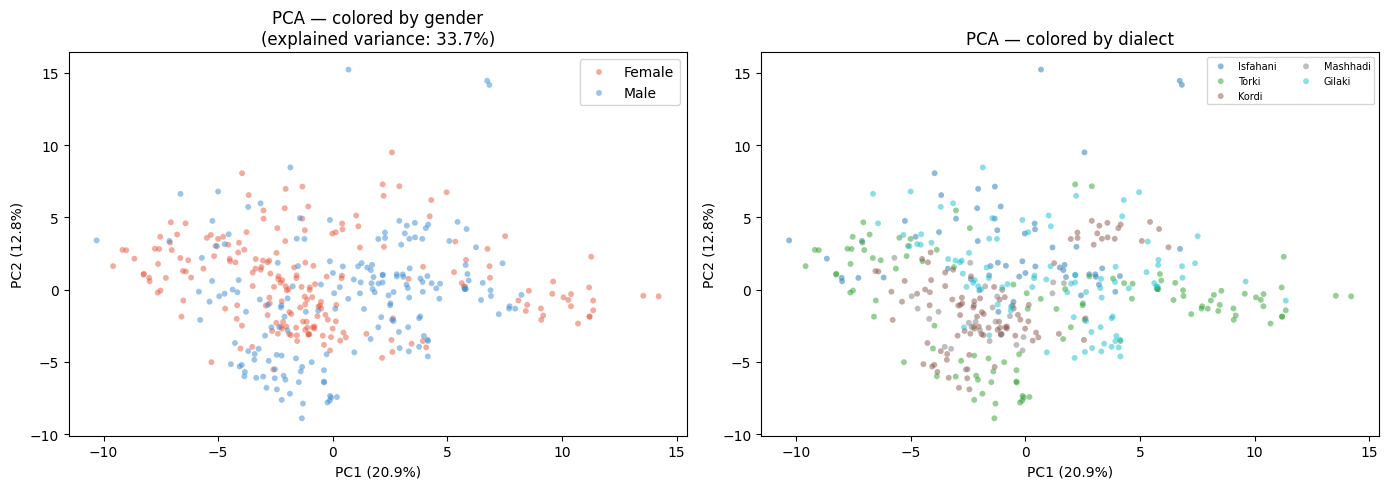


PCA explained variance — PC1: 20.9%,  PC2: 12.8%,  Total: 33.7%

Phase 2 complete. Final dataset ready for Phase 3.
Output file: /content/drive/MyDrive/ML_Phase2_Processed/features_dataset.csv


In [ ]:
feature_cols = [c for c in df_features.columns
                if c not in ['filename', 'dialect', 'gender', 'speaker_id']]

# --- 11.1  Missing value audit ---
missing      = df_features[feature_cols].isnull().sum()
missing_cols = missing[missing > 0]

if len(missing_cols) == 0:
    print("No missing values found in the feature matrix.")
else:
    print(f"Warning: {len(missing_cols)} features contain missing values:")
    print(missing_cols)
    # Fill with column mean so downstream models do not crash
    df_features[feature_cols] = df_features[feature_cols].fillna(
        df_features[feature_cols].mean()
    )
    print("Missing values filled with column means.")

# --- 11.2  Class balance ---
print("\n--- Gender distribution ---")
print(df_features['gender'].value_counts())
print("\n--- Dialect distribution ---")
print(df_features['dialect'].value_counts())

# --- 11.3  Feature distribution plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Pitch distribution by gender — most direct gender discriminator
sns.histplot(data=df_features, x='pitch_mean', hue='gender',
             kde=True, bins=40, ax=axes[0])
axes[0].set_title('Pitch (F0) distribution by gender')
axes[0].set_xlabel('Mean F0 (Hz)')
axes[0].set_ylabel('Count')

# MFCC-1 across dialects — energy-related, dialect-sensitive
sns.boxplot(data=df_features, x='dialect', y='mfcc_1_mean', ax=axes[1])
axes[1].set_title('MFCC-1 by dialect')
axes[1].set_xlabel('Dialect')
axes[1].tick_params(axis='x', rotation=45)

# Chroma mean energy across dialects — captures intonation differences
# We use the average energy across all 12 chroma bins as a summary
df_features['chroma_avg_mean'] = df_features[
    [f'chroma_{i}_mean' for i in range(1, 13)]
].mean(axis=1)
sns.boxplot(data=df_features, x='dialect', y='chroma_avg_mean', ax=axes[2])
axes[2].set_title('Chroma average energy by dialect')
axes[2].set_xlabel('Dialect')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(my_personal_drive, 'feature_distributions.png'), dpi=150)
plt.show()

# --- 11.4  PCA 2D projection ---
# We standardize all features before PCA because they live on very
# different scales (e.g., F0 in hundreds of Hz, RMS in the range 0-1).
X        = df_features[feature_cols].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: colored by gender
gender_palette = {'Female': '#E8593C', 'Male': '#3B8BD4'}
for gender, color in gender_palette.items():
    mask = df_features['gender'] == gender
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=gender, alpha=0.5, s=18, c=color, edgecolors='none')
axes[0].set_title(
    f'PCA — colored by gender\n'
    f'(explained variance: {pca.explained_variance_ratio_.sum():.1%})'
)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].legend()

# Right plot: colored by dialect
dialects = df_features['dialect'].unique()
palette  = plt.cm.tab10(np.linspace(0, 1, len(dialects)))
for dialect, color in zip(dialects, palette):
    mask = df_features['dialect'] == dialect
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=dialect, alpha=0.5, s=18, c=[color], edgecolors='none')
axes[1].set_title('PCA — colored by dialect')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(my_personal_drive, 'pca_projection.png'), dpi=150)
plt.show()

print(f"\nPCA explained variance — "
      f"PC1: {pca.explained_variance_ratio_[0]:.1%},  "
      f"PC2: {pca.explained_variance_ratio_[1]:.1%},  "
      f"Total: {pca.explained_variance_ratio_.sum():.1%}")
print("\nPhase 2 complete. Final dataset ready for Phase 3.")
print(f"Output file: {FEATURES_OUTPUT_CSV}")


In [ ]:
# --- 1. Basic shape check ---
print(f"Rows (files): {df_features.shape[0]}")
print(f"Columns (features + metadata): {df_features.shape[1]}")

# --- 2. Make sure all 4 metadata columns exist ---
print("\nMetadata columns:")
print(df_features[['filename', 'dialect', 'gender', 'speaker_id']].head(10))

# --- 3. Check feature columns are all numeric ---
feature_cols = [c for c in df_features.columns
                if c not in ['filename', 'dialect', 'gender', 'speaker_id']]
print(f"\nFeature columns: {len(feature_cols)}")
print(df_features[feature_cols].dtypes.value_counts())

# --- 4. Check for missing values ---
missing = df_features[feature_cols].isnull().sum().sum()
print(f"\nTotal missing values in features: {missing}")

# --- 5. Sanity check on pitch — females should be higher than males ---
print("\nPitch mean by gender:")
print(df_features.groupby('gender')['pitch_mean'].mean())

# --- 6. Preview the CSV saved to Drive ---
print("\nFirst row of saved CSV:")
df_check = pd.read_csv(FEATURES_OUTPUT_CSV)
display(df_check.head(3))

Rows (files): 379
Columns (features + metadata): 104

Metadata columns:
                              filename   dialect  gender speaker_id
0  G01_Isfahani_Female_F01_Voice01.mp3  Isfahani  Female        F01
1  G01_Isfahani_Female_F02_Voice02.mp3  Isfahani  Female        F02
2  G01_Isfahani_Female_F03_Voice03.mp3  Isfahani  Female        F03
3  G01_Isfahani_Female_F04_Voice01.mp3  Isfahani  Female        F04
4  G01_Isfahani_Female_F04_Voice02.mp3  Isfahani  Female        F04
5  G01_Isfahani_Female_F04_Voice03.mp3  Isfahani  Female        F04
6  G01_Isfahani_Female_F04_Voice04.mp3  Isfahani  Female        F04
7  G01_Isfahani_Female_F05_Voice01.mp3  Isfahani  Female        F05
8  G01_Isfahani_Female_F06_Voice01.mp3  Isfahani  Female        F06
9  G01_Isfahani_Female_F06_Voice02.mp3  Isfahani  Female        F06

Feature columns: 100
float32    77
float64    23
Name: count, dtype: int64

Total missing values in features: 0

Pitch mean by gender:
gender
Female    236.865248
Male      168.46

,filename,dialect,gender,speaker_id,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,...,sc_5_std,sc_6_mean,sc_6_std,sc_7_mean,sc_7_std,zcr_mean,zcr_std,rms_mean,rms_std,rms_max
0,G01_Isfahani_Female_F01_Voice01.mp3,Isfahani,Female,F01,-215.11180,115.127754,73.418800,55.477314,-9.480737,31.956133,...,6.375330,37.031834,10.676317,48.112700,6.170109,0.195894,0.184064,0.190916,0.142898,0.590285
1,G01_Isfahani_Female_F02_Voice02.mp3,Isfahani,Female,F02,-187.00636,101.497020,81.595695,42.561954,-7.178339,32.654213,...,4.320523,28.600674,9.713580,48.344904,6.463596,0.101539,0.077039,0.212381,0.151854,0.592788
2,G01_Isfahani_Female_F03_Voice03.mp3,Isfahani,Female,F03,-188.59941,102.653170,80.961440,38.569695,-12.883212,31.845823,...,5.231242,31.134739,11.362026,47.764734,6.735018,0.088570,0.078518,0.226515,0.134520,0.616568


In [ ]:
# Check what's inside the processed folder
print("Contents of ML_Phase2_Processed:")
for item in os.listdir('/content/drive/MyDrive/ML_Phase2_Processed'):
    print(f"  {item}")

# Check if Processed_Audio subfolder exists
processed_audio_path = '/content/drive/MyDrive/ML_Phase2_Processed/Processed_Audio'
if os.path.exists(processed_audio_path):
    files = os.listdir(processed_audio_path)
    print(f"\nProcessed_Audio contains {len(files)} files")
    print("First 5:", files[:5])
else:
    print("\nProcessed_Audio folder does NOT exist!")

# Also check what path the handoff CSV has for filenames
print("\nSample filenames from handoff CSV:")
print(df_handoff['filename'].head(10).tolist())

Contents of ML_Phase2_Processed:
  Processed_Audio
  processed_metadata_handoff.gsheet
  processed_metadata_handoff.csv
  features_dataset.csv
  feature_distributions.png
  pca_projection.png

Processed_Audio contains 379 files
First 5: ['G01_Isfahani_Female_F02_Voice02.mp3', 'G01_Isfahani_Female_F03_Voice03.mp3', 'G01_Isfahani_Female_F01_Voice01.mp3', 'G01_Isfahani_Female_F04_Voice01.mp3', 'G01_Isfahani_Female_F04_Voice02.mp3']

Sample filenames from handoff CSV:
['G01_Isfahani_Female_F01_Voice01.mp3', 'G01_Isfahani_Female_F02_Voice02.mp3', 'G01_Isfahani_Female_F03_Voice03.mp3', 'G01_Isfahani_Female_F04_Voice01.mp3', 'G01_Isfahani_Female_F04_Voice02.mp3', 'G01_Isfahani_Female_F04_Voice03.mp3', 'G01_Isfahani_Female_F04_Voice04.mp3', 'G01_Isfahani_Female_F05_Voice01.mp3', 'G01_Isfahani_Female_F06_Voice01.mp3', 'G01_Isfahani_Female_F06_Voice02.mp3']
